
# Crime Pattern Detection using Data Mining

This notebook performs an end‑to‑end data mining workflow on an Indian crime dataset:

1. Data loading, cleaning and preprocessing  
2. Feature selection and feature engineering  
3. Exploratory Data Analysis (EDA) – **multiple visualizations**  
4. Classification models for crime level prediction  
5. Clustering using **K‑Means** (cluster map using PCA)  
6. Association Rule Mining using **FP‑Growth**  
7. Model evaluation for each model  
8. Saving trained models with **pickle**

> **Note:** Make sure the CSV file `01_District_wise_crimes_committed_IPC_2001_2012.csv` is in the same folder as this notebook, or update the `DATA_PATH` variable below.


In [2]:

# ==============================
# 1. Imports & Global Settings
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Association rule mining
# If not installed: pip install mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules

import pickle
import os

# Plot settings
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Show all columns
pd.set_option("display.max_columns", None)

# Data path (change if needed)
DATA_PATH = "01_District_wise_crimes_committed_IPC_2001_2012.csv"


In [3]:

# ==============================
# 2. Load Data
# ==============================
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (9017, 33)


,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,KIDNAPPING AND ABDUCTION OF OTHERS,DACOITY,PREPARATION AND ASSEMBLY FOR DACOITY,ROBBERY,BURGLARY,THEFT,AUTO THEFT,OTHER THEFT,RIOTS,CRIMINAL BREACH OF TRUST,CHEATING,COUNTERFIETING,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,30,16,9,0,41,198,199,22,177,78,16,104,1,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,30,23,8,0,16,191,366,57,309,168,11,65,8,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,34,25,4,0,14,237,723,164,559,156,33,209,9,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,20,5,1,0,4,98,173,36,137,164,12,37,2,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,26,23,4,0,25,437,1021,150,871,70,50,220,3,41,1244,12,109,58,247,0,431,2313,6507


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9017 entries, 0 to 9016
Data columns (total 33 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   STATE/UT                                             9017 non-null   object
 1   DISTRICT                                             9017 non-null   object
 2   YEAR                                                 9017 non-null   int64 
 3   MURDER                                               9017 non-null   int64 
 4   ATTEMPT TO MURDER                                    9017 non-null   int64 
 5   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER            9017 non-null   int64 
 6   RAPE                                                 9017 non-null   int64 
 7   CUSTODIAL RAPE                                       9017 non-null   int64 
 8   OTHER RAPE                                           9017 non-null   int64 
 9

None


## Data Cleaning & Preprocessing

Steps:
- Check and handle missing values  
- Remove duplicate rows (if any)  
- Basic consistency checks  
- Separate categorical and numerical features


In [5]:

# ==============================
# 3. Data Cleaning & Preprocessing
# ==============================

# Check for missing values
print("Missing values per column:")
display(df.isna().sum())

# Simple strategy: drop rows with any missing value (can be changed to imputation)
df_clean = df.dropna().copy()
print("Shape after dropping NA:", df_clean.shape)

# Remove duplicate rows
before_dups = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after_dups = df_clean.shape[0]
print(f"Removed {before_dups - after_dups} duplicate rows")

# Identify categorical and numerical columns
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns (first 10):", num_cols[:10])


Missing values per column:


STATE/UT                                               0
DISTRICT                                               0
YEAR                                                   0
MURDER                                                 0
ATTEMPT TO MURDER                                      0
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER              0
RAPE                                                   0
CUSTODIAL RAPE                                         0
OTHER RAPE                                             0
KIDNAPPING & ABDUCTION                                 0
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS            0
KIDNAPPING AND ABDUCTION OF OTHERS                     0
DACOITY                                                0
PREPARATION AND ASSEMBLY FOR DACOITY                   0
ROBBERY                                                0
BURGLARY                                               0
THEFT                                                  0
AUTO THEFT                     

Shape after dropping NA: (9017, 33)
Removed 0 duplicate rows
Categorical columns: ['STATE/UT', 'DISTRICT']
Numeric columns (first 10): ['YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS']



## Feature Engineering & Target Creation

- Create total crime features (sanity check vs `TOTAL IPC CRIMES`)  
- Aggregate numeric crime types to create `TOTAL_CRIMES_ENGINEERED`  
- Derive a **classification label**:
  - `Crime_Level` = `0` (Low/Medium) vs `1` (High) based on median of total crimes.


In [6]:

# ==============================
# 4. Feature Engineering
# ==============================

df_fe = df_clean.copy()

# Sum of all crime numeric columns except YEAR (and any obvious id columns)
num_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
cols_for_total = [c for c in num_cols if c not in ["YEAR"]]

df_fe["TOTAL_CRIMES_ENGINEERED"] = df_fe[cols_for_total].sum(axis=1)

# Compare with existing TOTAL IPC CRIMES if present
if "TOTAL IPC CRIMES" in df_fe.columns:
    corr_total = df_fe["TOTAL_CRIMES_ENGINEERED"].corr(df_fe["TOTAL IPC CRIMES"])
    print("Correlation between engineered total and TOTAL IPC CRIMES:", corr_total)

# Create a binary target based on median of TOTAL_CRIMES_ENGINEERED
threshold = df_fe["TOTAL_CRIMES_ENGINEERED"].median()
df_fe["Crime_Level"] = (df_fe["TOTAL_CRIMES_ENGINEERED"] > threshold).astype(int)

df_fe[["STATE/UT", "DISTRICT", "YEAR", "TOTAL_CRIMES_ENGINEERED", "Crime_Level"]].head()


Correlation between engineered total and TOTAL IPC CRIMES: 0.9994865984132666


,STATE/UT,DISTRICT,YEAR,TOTAL_CRIMES_ENGINEERED,Crime_Level
0,ANDHRA PRADESH,ADILABAD,2001,8603,1
1,ANDHRA PRADESH,ANANTAPUR,2001,8692,1
2,ANDHRA PRADESH,CHITTOOR,2001,12445,1
3,ANDHRA PRADESH,CUDDAPAH,2001,6498,1
4,ANDHRA PRADESH,EAST GODAVARI,2001,14107,1



## Feature Selection

- Drop highly identifier‑like fields (`DISTRICT`, etc.) for modeling  
- Use numeric crime counts as input features


In [7]:

# ==============================
# 5. Feature Selection
# ==============================

# Input features: all numeric crime columns except YEAR and the target itself
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c not in ["YEAR", "Crime_Level"]
]

print("Number of features used:", len(feature_cols))

X = df_fe[feature_cols].values
y = df_fe["Crime_Level"].values

X.shape, y.shape


Number of features used: 31


((9017, 31), (9017,))


# Exploratory Data Analysis (EDA)

We will create **multiple plots** to understand patterns in the data:

1. Distribution of total crimes  
2. Crimes over years (trend)  
3. Top 10 districts by total crimes  
4. Boxplot of crimes by State/UT  
5. Correlation heatmap of major crime types  
6. Pairplot (subset of features)


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


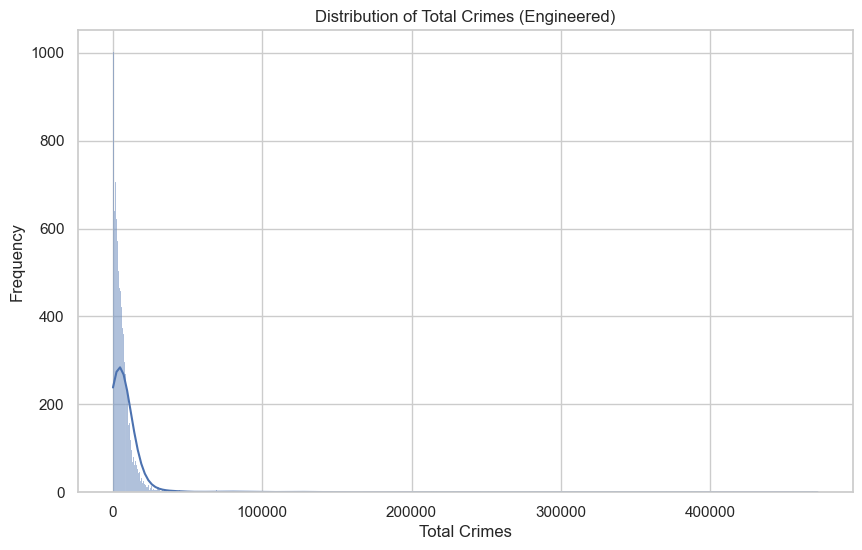

In [8]:

# ==============================
# 6.1 Distribution of total crimes
# ==============================
plt.figure()
sns.histplot(df_fe["TOTAL_CRIMES_ENGINEERED"], kde=True)
plt.title("Distribution of Total Crimes (Engineered)")
plt.xlabel("Total Crimes")
plt.ylabel("Frequency")
plt.show()


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with

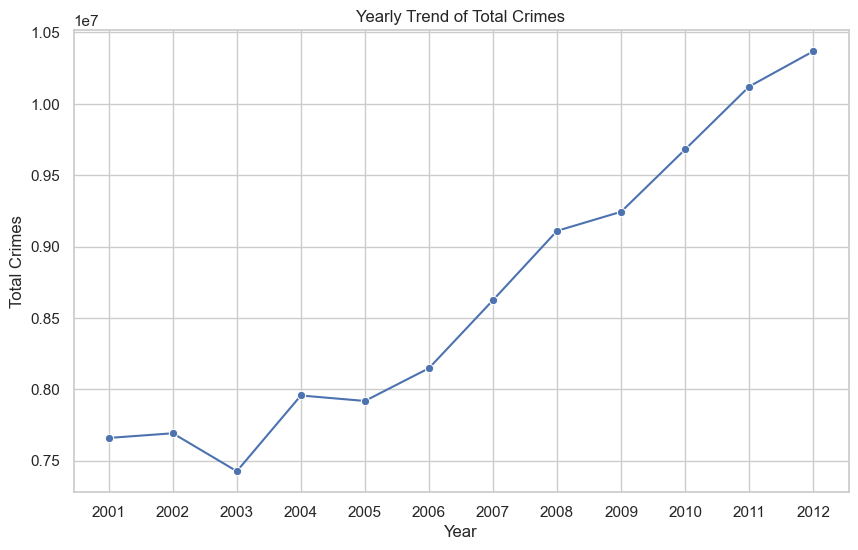

In [9]:

# ==============================
# 6.2 Trend of total crimes over years
# ==============================
yearly_trend = df_fe.groupby("YEAR")["TOTAL_CRIMES_ENGINEERED"].sum().reset_index()

plt.figure()
sns.lineplot(data=yearly_trend, x="YEAR", y="TOTAL_CRIMES_ENGINEERED", marker="o")
plt.title("Yearly Trend of Total Crimes")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.xticks(yearly_trend["YEAR"].unique())
plt.show()


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if

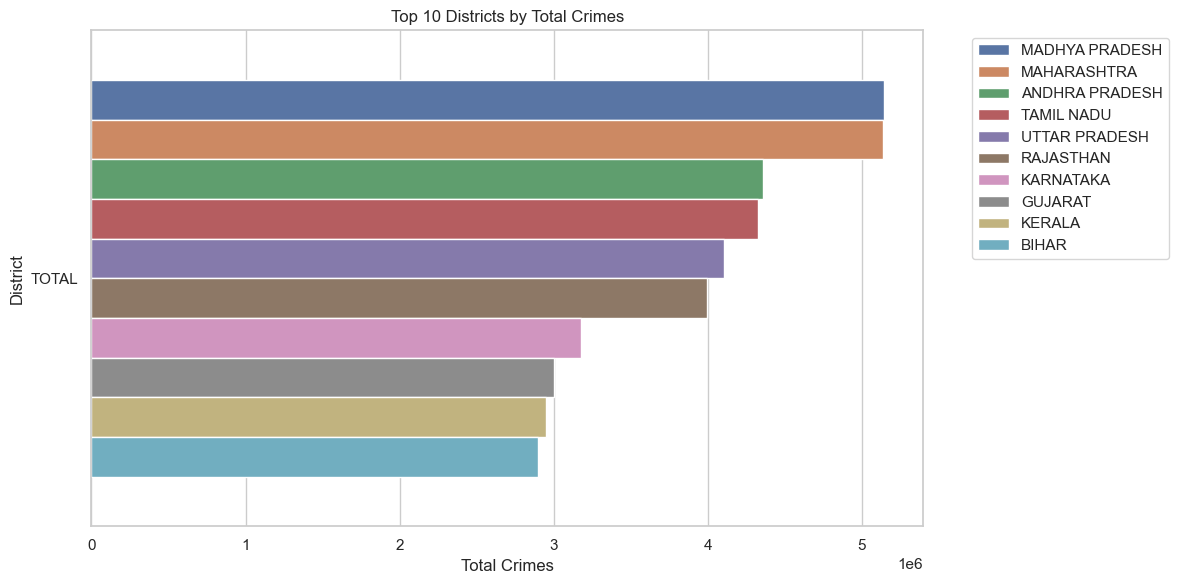

In [10]:

# ==============================
# 6.3 Top 10 districts by total crimes
# ==============================
district_totals = (
    df_fe.groupby(["STATE/UT", "DISTRICT"])["TOTAL_CRIMES_ENGINEERED"]
    .sum()
    .reset_index()
    .sort_values(by="TOTAL_CRIMES_ENGINEERED", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=district_totals,
    x="TOTAL_CRIMES_ENGINEERED",
    y="DISTRICT",
    hue="STATE/UT"
)
plt.title("Top 10 Districts by Total Crimes")
plt.xlabel("Total Crimes")
plt.ylabel("District")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


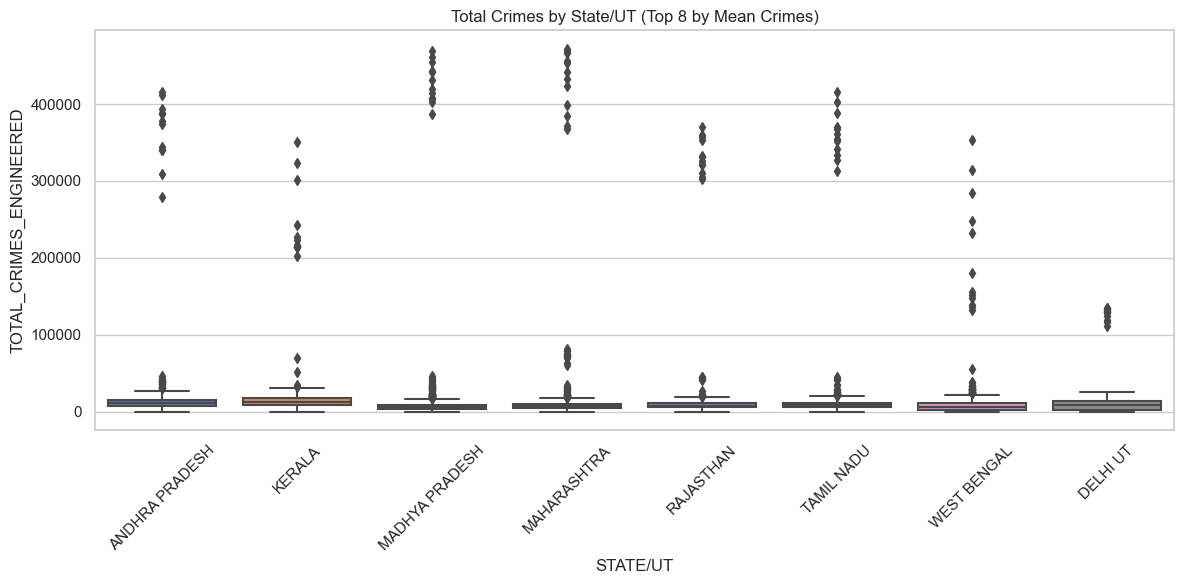

In [11]:

# ==============================
# 6.4 Boxplot of total crimes by State/UT (top 8 states by mean crimes)
# ==============================
state_means = (
    df_fe.groupby("STATE/UT")["TOTAL_CRIMES_ENGINEERED"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_fe[df_fe["STATE/UT"].isin(state_means)],
    x="STATE/UT",
    y="TOTAL_CRIMES_ENGINEERED"
)
plt.title("Total Crimes by State/UT (Top 8 by Mean Crimes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


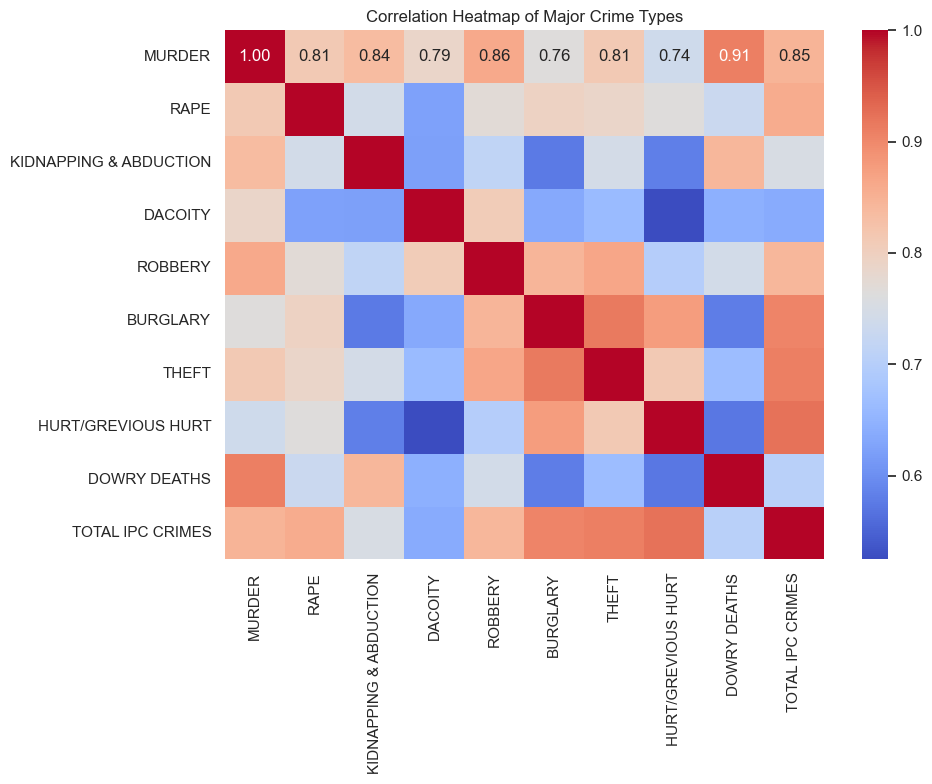

In [12]:

# ==============================
# 6.5 Correlation heatmap of selected major crime types
# ==============================
# Select a subset of important crime categories for clarity
selected_cols = [
    col for col in df_fe.columns
    if col in [
        "MURDER",
        "RAPE",
        "KIDNAPPING & ABDUCTION",
        "DACOITY",
        "ROBBERY",
        "BURGLARY",
        "THEFT",
        "HURT/GREVIOUS HURT",
        "DOWRY DEATHS",
        "TOTAL IPC CRIMES"
    ]
]

corr_matrix = df_fe[selected_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Major Crime Types")
plt.tight_layout()
plt.show()


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if

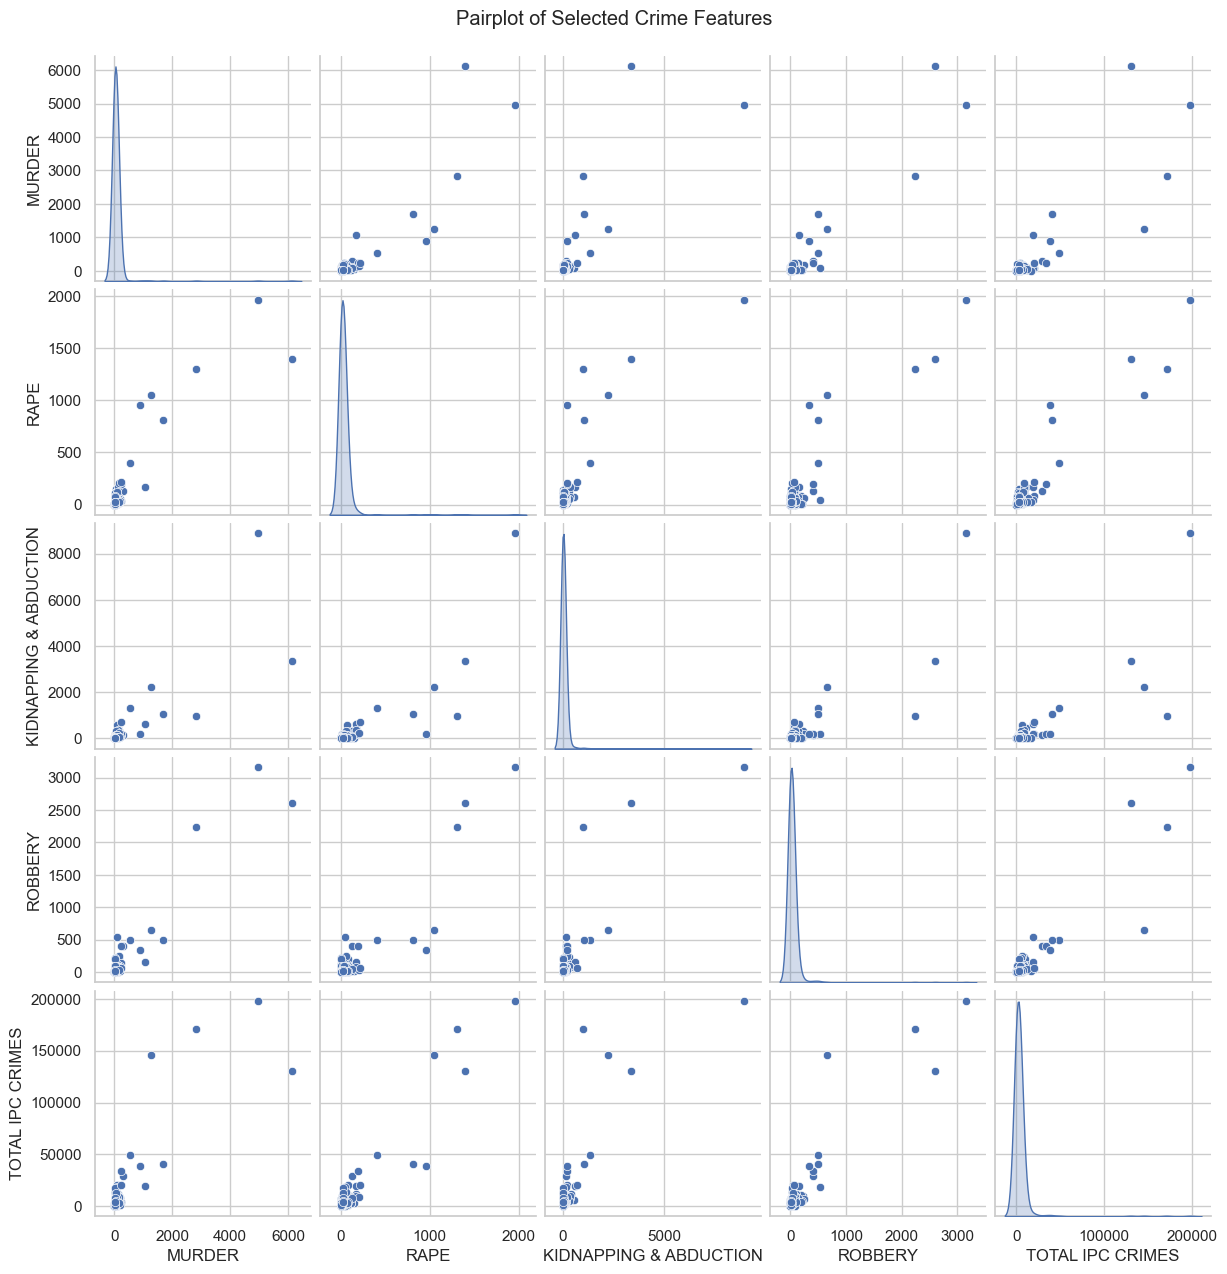

In [13]:

# ==============================
# 6.6 Pairplot for a subset of features
# ==============================
subset_cols = [
    col for col in selected_cols
    if col in ["MURDER", "RAPE", "KIDNAPPING & ABDUCTION", "ROBBERY", "TOTAL IPC CRIMES"]
]

sns.pairplot(df_fe[subset_cols].sample(min(500, len(df_fe))), diag_kind="kde")
plt.suptitle("Pairplot of Selected Crime Features", y=1.02)
plt.show()



# Classification Modeling

We will:
- Split the data into train and test sets  
- Standardize features  
- Train multiple classifiers (Logistic Regression, Random Forest)  
- Evaluate each model (accuracy, classification report, confusion matrix)


In [14]:

# ==============================
# 7. Train-Test Split & Scaling
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((7213, 31), (1804, 31))

Logistic Regression Accuracy: 0.9828159645232816

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       903
           1       0.98      0.98      0.98       901

    accuracy                           0.98      1804
   macro avg       0.98      0.98      0.98      1804
weighted avg       0.98      0.98      0.98      1804



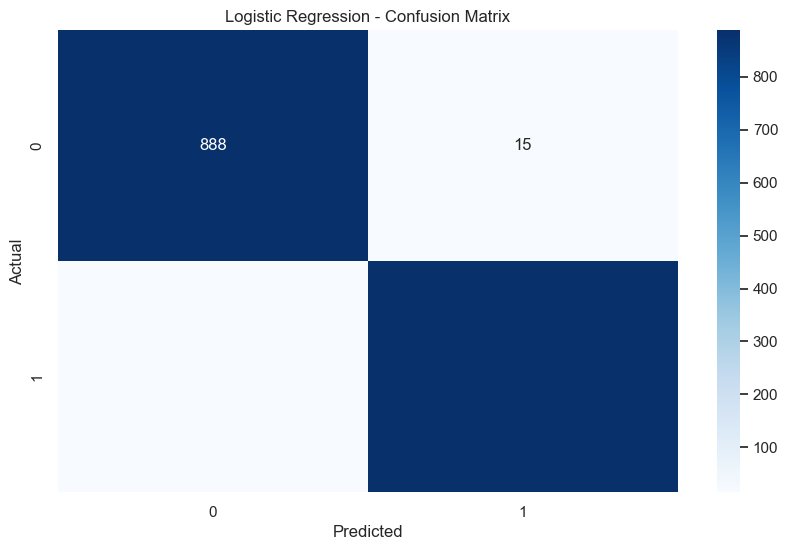

In [15]:

# ==============================
# 8. Logistic Regression Classifier
# ==============================
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       903
           1       1.00      1.00      1.00       901

    accuracy                           1.00      1804
   macro avg       1.00      1.00      1.00      1804
weighted avg       1.00      1.00      1.00      1804



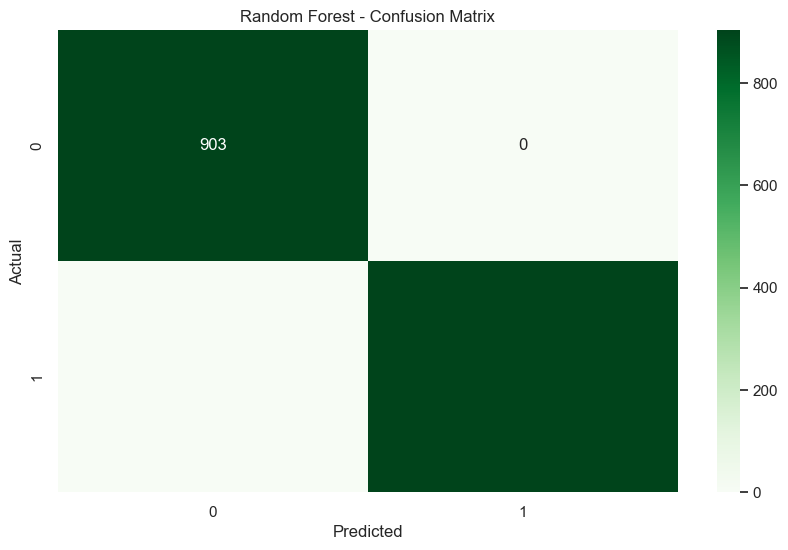

In [16]:

# ==============================
# 9. Random Forest Classifier
# ==============================
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)  # RF works fine on unscaled data

y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# Clustering with K‑Means

Steps:
- Use standardized numeric features  
- Apply K‑Means clustering  
- Use PCA to reduce features to 2D for visualization  
- Plot a **cluster map** (scatter plot in PCA space)


Cluster
0    8803
1      55
2     131
3      28
Name: count, dtype: int64


c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if

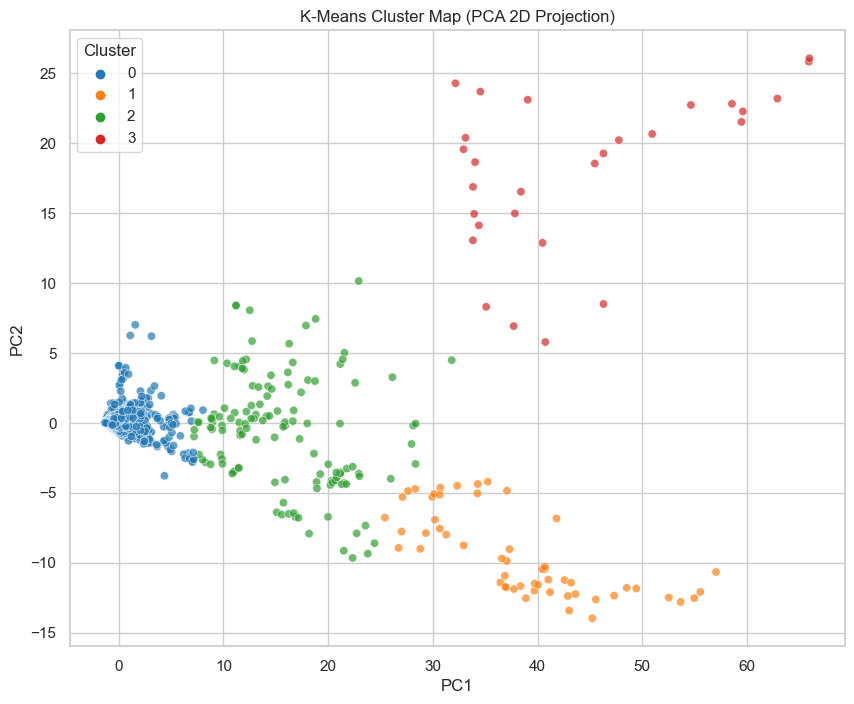

In [17]:

# ==============================
# 10. K‑Means Clustering
# ==============================
# Use scaled features for clustering
scaler_cluster = StandardScaler()
X_scaled_for_cluster = scaler_cluster.fit_transform(df_fe[feature_cols])

# Choose number of clusters (can tune using elbow method)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_for_cluster)

df_fe["Cluster"] = cluster_labels

# Cluster counts
print(df_fe["Cluster"].value_counts().sort_index())

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_for_cluster)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = cluster_labels
df_pca["STATE/UT"] = df_fe["STATE/UT"].values
df_pca["DISTRICT"] = df_fe["DISTRICT"].values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("K-Means Cluster Map (PCA 2D Projection)")
plt.legend(title="Cluster")
plt.show()



# Association Rule Mining (FP‑Growth)

To discover relationships between different crime types, we:

- Convert crime counts to binary values (1 = crime present, 0 = none)  
- Use **FP‑Growth** to find frequent itemsets  
- Generate association rules (confidence, lift)


In [21]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Use only major crime types
crime_item_cols = [
    'MURDER',
    'RAPE',
    'THEFT',
    'RIOTS',
    'ROBBERY',
    'BURGLARY',
    'KIDNAPPING & ABDUCTION'
]

# Median-based binarization (reduces density)
crime_binary = df_fe[crime_item_cols].apply(lambda x: x > x.median())

print("Binary matrix shape:", crime_binary.shape)

# FP-Growth (FAST)
frequent_itemsets = fpgrowth(
    crime_binary,
    min_support=0.3,
    use_colnames=True
)

# Limit itemset size
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets[frequent_itemsets['length'] <= 3]

print("Frequent itemsets:", frequent_itemsets.shape[0])
display(frequent_itemsets.head())

# Association Rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7
).sort_values(by="lift", ascending=False)

display(
    rules[['antecedents','consequents','support','confidence','lift']].head(10)
)


Binary matrix shape: (9017, 7)
Frequent itemsets: 30


,support,itemsets,length
0,0.498503,(BURGLARY),1
1,0.498059,(RIOTS),1
2,0.495508,(KIDNAPPING & ABDUCTION),1
3,0.493290,(ROBBERY),1
4,0.492736,(RAPE),1


,antecedents,consequents,support,confidence,lift
11,"(ROBBERY, BURGLARY)",(THEFT),0.318842,0.878667,1.762613
28,"(ROBBERY, KIDNAPPING & ABDUCTION)",(MURDER),0.300211,0.858820,1.745318
10,"(ROBBERY, THEFT)",(BURGLARY),0.318842,0.841874,1.688805
30,"(KIDNAPPING & ABDUCTION, MURDER)",(ROBBERY),0.300211,0.810965,1.643990
12,"(THEFT, BURGLARY)",(ROBBERY),0.318842,0.808493,1.638979
29,"(ROBBERY, MURDER)",(KIDNAPPING & ABDUCTION),0.300211,0.804219,1.623017
32,(BURGLARY),(THEFT),0.394366,0.791101,1.586954
31,(THEFT),(BURGLARY),0.394366,0.791101,1.586954
8,(ROBBERY),(THEFT),0.378729,0.767761,1.540133
9,(THEFT),(ROBBERY),0.378729,0.759733,1.540133



# Model Evaluation Summary

Below we collect the key evaluation metrics for comparison.


In [22]:

# ==============================
# 12. Model Evaluation Summary
# ==============================
eval_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf]
})

display(eval_summary)


,Model,Accuracy
0,Logistic Regression,0.982816
1,Random Forest,1.000000



# Save Trained Models (Pickle)

We save:
- `scaler` used for classification  
- `Logistic Regression` model  
- `Random Forest` model  
- `K‑Means` clustering model


In [23]:

# ==============================
# 13. Save Models with Pickle
# ==============================
os.makedirs("models", exist_ok=True)

with open(os.path.join("models", "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join("models", "log_reg_model.pkl"), "wb") as f:
    pickle.dump(log_reg, f)

with open(os.path.join("models", "rf_model.pkl"), "wb") as f:
    pickle.dump(rf_clf, f)

with open(os.path.join("models", "kmeans_model.pkl"), "wb") as f:
    pickle.dump(kmeans, f)

print("Models saved in 'models/' folder:")
print(os.listdir("models"))


Models saved in 'models/' folder:
['kmeans_model.pkl', 'log_reg_model.pkl', 'rf_model.pkl', 'scaler.pkl']
